# Advanced VaR Models and Performance Comparison

This notebook extends the core market-risk engine by implementing:

- EWMA Parametric VaR
- Weighted Historical Simulation
- Monte Carlo VaR
- Expected Shortfall
- Rolling model backtesting
- Comparative model-performance analysis

In [93]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import xlogy
from scipy.stats import chi2, norm

# Identify the repository root.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\Pranav\Desktop\market-risk-engine


In [94]:
returns_path = PROCESSED_DATA_DIR / "daily_returns.csv"
pnl_path = PROCESSED_DATA_DIR / "daily_pnl.csv"

if not returns_path.exists():
    raise FileNotFoundError(
        "daily_returns.csv was not found. Run the Day 1 notebook first."
    )

if not pnl_path.exists():
    raise FileNotFoundError(
        "daily_pnl.csv was not found. Run the Day 1 notebook first."
    )

returns = pd.read_csv(
    returns_path,
    index_col="date",
    parse_dates=True,
)

pnl_data = pd.read_csv(
    pnl_path,
    index_col="date",
    parse_dates=True,
)

returns = returns.sort_index()
pnl_data = pnl_data.sort_index()

portfolio_pnl = pnl_data["portfolio_pnl_eur"]

print(f"Return observations: {len(returns):,}")
print(f"P&L observations: {len(portfolio_pnl):,}")
print(
    f"Sample: {portfolio_pnl.index.min().date()} to "
    f"{portfolio_pnl.index.max().date()}"
)

display(returns.head())
display(pnl_data.head())

Return observations: 2,654
P&L observations: 2,654
Sample: 2016-01-05 to 2026-07-31


,Equity index,Government bond proxy,EUR/USD,Gold
date,,,,
2016-01-05,0.001691,-0.004035,-0.002436,0.002819
2016-01-06,-0.012614,0.013476,-0.006978,0.014441
2016-01-07,-0.023992,0.001795,0.002512,0.014140
2016-01-08,-0.010976,0.004478,0.013636,-0.004428
2016-01-11,0.000990,-0.010943,0.001379,-0.008895


,Equity index_pnl_eur,Government bond proxy_pnl_eur,EUR/USD_pnl_eur,Gold_pnl_eur,portfolio_pnl_eur
date,,,,,
2016-01-05,422.838435,-1210.471878,-487.227441,422.782949,-852.077936
2016-01-06,-3153.540592,4042.717303,-1395.625824,2166.114353,1659.665240
2016-01-07,-5998.008910,538.490434,502.315779,2120.956410,-2836.246287
2016-01-08,-2744.048204,1343.400326,2727.116186,-664.156214,662.312094
2016-01-11,247.484229,-3283.004797,275.711638,-1334.219964,-4094.028895


In [95]:
assert not returns.empty
assert not pnl_data.empty

assert returns.index.is_monotonic_increasing
assert pnl_data.index.is_monotonic_increasing

assert not returns.index.duplicated().any()
assert not pnl_data.index.duplicated().any()

assert not returns.isna().any().any()
assert not pnl_data.isna().any().any()

assert np.isfinite(returns.to_numpy()).all()
assert np.isfinite(pnl_data.to_numpy()).all()

assert returns.index.equals(pnl_data.index)

print("Day 1 data loaded and validated successfully.")

Day 1 data loaded and validated successfully.


## 1. Model configuration

All models will initially be evaluated using:

- A one-day holding period
- A 99% confidence level
- A 250-day rolling estimation window
- A fixed EUR 900,000 portfolio
- One-day-ahead out-of-sample backtesting

In [96]:
CONFIDENCE_LEVEL = 0.99
TAIL_PROBABILITY = 1 - CONFIDENCE_LEVEL
LOOKBACK_WINDOW = 250

# RiskMetrics commonly uses 0.94 for daily EWMA volatility.
EWMA_LAMBDA = 0.94

MONTE_CARLO_SIMULATIONS = 100_000
RANDOM_SEED = 42

NOTIONALS = pd.Series(
    {
        "Equity index": 250_000,
        "Government bond proxy": 300_000,
        "EUR/USD": 200_000,
        "Gold": 150_000,
    },
    dtype=float,
)

assert list(NOTIONALS.index) == list(returns.columns)
assert NOTIONALS.sum() == 900_000

print(f"Confidence level: {CONFIDENCE_LEVEL:.0%}")
print(f"Lookback window: {LOOKBACK_WINDOW} days")
print(f"EWMA lambda: {EWMA_LAMBDA}")
print(f"Monte Carlo simulations: {MONTE_CARLO_SIMULATIONS:,}")

display(NOTIONALS.to_frame("notional_eur"))

Confidence level: 99%
Lookback window: 250 days
EWMA lambda: 0.94
Monte Carlo simulations: 100,000


,notional_eur
Equity index,250000.0
Government bond proxy,300000.0
EUR/USD,200000.0
Gold,150000.0


## 2. EWMA Parametric VaR

The Exponentially Weighted Moving Average model assigns greater weight to
recent market observations.

The covariance matrix evolves according to:

\[
\Sigma_t
=
\lambda\Sigma_{t-1}
+
(1-\lambda)r_{t-1}r_{t-1}^{\top},
\]

where:

- \(\Sigma_t\) is the covariance matrix used to forecast risk on date \(t\)
- \(r_{t-1}\) is the vector of returns observed on the preceding date
- \(\lambda\) is the decay factor

A decay factor of 0.94 is used. Lower values make the model react more quickly
to new observations, while higher values produce smoother volatility estimates.

In [97]:
def calculate_ewma_covariance(
    return_data: pd.DataFrame,
    decay_factor: float = 0.94,
) -> pd.DataFrame:
    """
    Calculate a zero-mean EWMA covariance matrix.

    More recent returns receive larger weights.

    Parameters
    ----------
    return_data:
        Daily return observations ordered from oldest to newest.
    decay_factor:
        EWMA lambda parameter between zero and one.

    Returns
    -------
    pd.DataFrame
        Exponentially weighted covariance matrix.
    """
    if return_data.empty:
        raise ValueError("return_data cannot be empty.")

    if not 0 < decay_factor < 1:
        raise ValueError("decay_factor must lie between zero and one.")

    if return_data.isna().any().any():
        raise ValueError("return_data contains missing observations.")

    return_matrix = return_data.to_numpy(dtype=float)
    observations = len(return_data)

    # Oldest observation receives the smallest weight.
    powers = np.arange(observations - 1, -1, -1)

    weights = (
        (1 - decay_factor)
        * decay_factor**powers
    )

    # Normalise because the finite sample weights do not sum exactly to one.
    weights = weights / weights.sum()

    covariance_matrix = np.einsum(
        "t,ti,tj->ij",
        weights,
        return_matrix,
        return_matrix,
    )

    return pd.DataFrame(
        covariance_matrix,
        index=return_data.columns,
        columns=return_data.columns,
    )

In [98]:
recent_returns = returns.iloc[-LOOKBACK_WINDOW:]

ewma_covariance = calculate_ewma_covariance(
    return_data=recent_returns,
    decay_factor=EWMA_LAMBDA,
)

notional_vector = NOTIONALS.reindex(
    returns.columns
).to_numpy(dtype=float)

ewma_portfolio_variance = float(
    notional_vector
    @ ewma_covariance.to_numpy()
    @ notional_vector
)

if ewma_portfolio_variance < 0:
    raise RuntimeError(
        "The calculated portfolio variance is negative."
    )

ewma_portfolio_volatility = np.sqrt(
    ewma_portfolio_variance
)

ewma_z_score = norm.ppf(CONFIDENCE_LEVEL)

ewma_var_eur = (
    ewma_z_score
    * ewma_portfolio_volatility
)

ewma_es_eur = (
    ewma_portfolio_volatility
    * norm.pdf(ewma_z_score)
    / TAIL_PROBABILITY
)

ewma_current_results = pd.DataFrame(
    {
        "model": ["EWMA Parametric Normal"],
        "confidence_level": [CONFIDENCE_LEVEL],
        "lookback": [LOOKBACK_WINDOW],
        "lambda": [EWMA_LAMBDA],
        "portfolio_volatility_eur": [
            ewma_portfolio_volatility
        ],
        "var_eur": [ewma_var_eur],
        "expected_shortfall_eur": [ewma_es_eur],
    }
)

assert ewma_es_eur >= ewma_var_eur

display(
    ewma_current_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "lambda": "{:.2f}",
            "portfolio_volatility_eur": "EUR {:,.2f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,confidence_level,lookback,lambda,portfolio_volatility_eur,var_eur,expected_shortfall_eur
0,EWMA Parametric Normal,99%,250,0.94,"EUR 4,631.24","EUR 10,773.87","EUR 12,343.24"


In [99]:
current_model_comparison = pd.DataFrame(
    {
        "model": [
            "Historical Simulation",
            "Parametric Normal",
            "EWMA Parametric Normal",
        ],
        "var_eur": [
            12_669.90,
            10_698.74,
            ewma_var_eur,
        ],
        "expected_shortfall_eur": [
            14_999.77,
            12_257.16,
            ewma_es_eur,
        ],
    }
)

display(
    current_model_comparison.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,var_eur,expected_shortfall_eur
0,Historical Simulation,"EUR 12,669.90","EUR 14,999.77"
1,Parametric Normal,"EUR 10,698.74","EUR 12,257.16"
2,EWMA Parametric Normal,"EUR 10,773.87","EUR 12,343.24"


### 2.1 Rolling EWMA backtest

The rolling EWMA backtest begins with a covariance matrix estimated from the
first 250 observations.

For every subsequent date:

1. The existing covariance matrix generates the one-day VaR forecast.
2. The forecast is compared with realised portfolio P&L.
3. The covariance matrix is updated using the newly observed return.
4. The updated covariance matrix is used only for the following forecast.

This ordering prevents look-ahead bias.

In [100]:
return_matrix = returns.to_numpy(dtype=float)

initial_return_sample = return_matrix[
    :LOOKBACK_WINDOW
]

current_covariance = np.cov(
    initial_return_sample,
    rowvar=False,
    ddof=1,
)

rolling_ewma_records = []

for observation_number in range(
    LOOKBACK_WINDOW,
    len(returns),
):
    forecast_date = returns.index[observation_number]

    portfolio_variance = float(
        notional_vector
        @ current_covariance
        @ notional_vector
    )

    # Protect against tiny negative values caused by numerical rounding.
    portfolio_variance = max(
        portfolio_variance,
        0.0,
    )

    portfolio_volatility = np.sqrt(
        portfolio_variance
    )

    forecast_var = (
        ewma_z_score
        * portfolio_volatility
    )

    actual_pnl = float(
        portfolio_pnl.iloc[observation_number]
    )

    exception = actual_pnl < -forecast_var

    rolling_ewma_records.append(
        {
            "date": forecast_date,
            "actual_pnl_eur": actual_pnl,
            "ewma_volatility_eur": portfolio_volatility,
            "ewma_var_eur": forecast_var,
            "ewma_exception": exception,
        }
    )

    # Update only after evaluating the current day's forecast.
    observed_return = return_matrix[
        observation_number
    ].reshape(-1, 1)

    current_covariance = (
        EWMA_LAMBDA * current_covariance
        + (1 - EWMA_LAMBDA)
        * (
            observed_return
            @ observed_return.T
        )
    )

ewma_backtest_results = (
    pd.DataFrame(rolling_ewma_records)
    .set_index("date")
)

assert (
    len(ewma_backtest_results)
    == len(returns) - LOOKBACK_WINDOW
)

assert (
    ewma_backtest_results["ewma_var_eur"] > 0
).all()

display(ewma_backtest_results.head())

,actual_pnl_eur,ewma_volatility_eur,ewma_var_eur,ewma_exception
date,,,,
2016-12-30,1654.611656,3356.316722,7807.960270,False
2017-01-03,2194.106621,3279.212498,7628.589022,False
2017-01-04,2403.266442,3224.420376,7501.123486,False
2017-01-05,8378.931018,3181.134221,7400.424831,False
2017-01-06,-965.687886,3704.703380,8618.428832,False


In [101]:
ewma_observations = len(
    ewma_backtest_results
)

ewma_expected_exceptions = (
    ewma_observations
    * TAIL_PROBABILITY
)

ewma_actual_exceptions = int(
    ewma_backtest_results[
        "ewma_exception"
    ].sum()
)

ewma_exception_summary = pd.DataFrame(
    {
        "model": ["EWMA Parametric Normal"],
        "observations": [ewma_observations],
        "expected_exceptions": [
            ewma_expected_exceptions
        ],
        "actual_exceptions": [
            ewma_actual_exceptions
        ],
        "expected_exception_rate": [
            TAIL_PROBABILITY
        ],
        "actual_exception_rate": [
            ewma_actual_exceptions
            / ewma_observations
        ],
    }
)

ewma_exception_summary[
    "exception_difference"
] = (
    ewma_exception_summary[
        "actual_exceptions"
    ]
    - ewma_exception_summary[
        "expected_exceptions"
    ]
)

display(
    ewma_exception_summary.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_exception_rate": "{:.2%}",
            "actual_exception_rate": "{:.2%}",
            "exception_difference": "{:+.2f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_exception_rate,actual_exception_rate,exception_difference
0,EWMA Parametric Normal,2404,24.04,47,1.00%,1.96%,+22.96


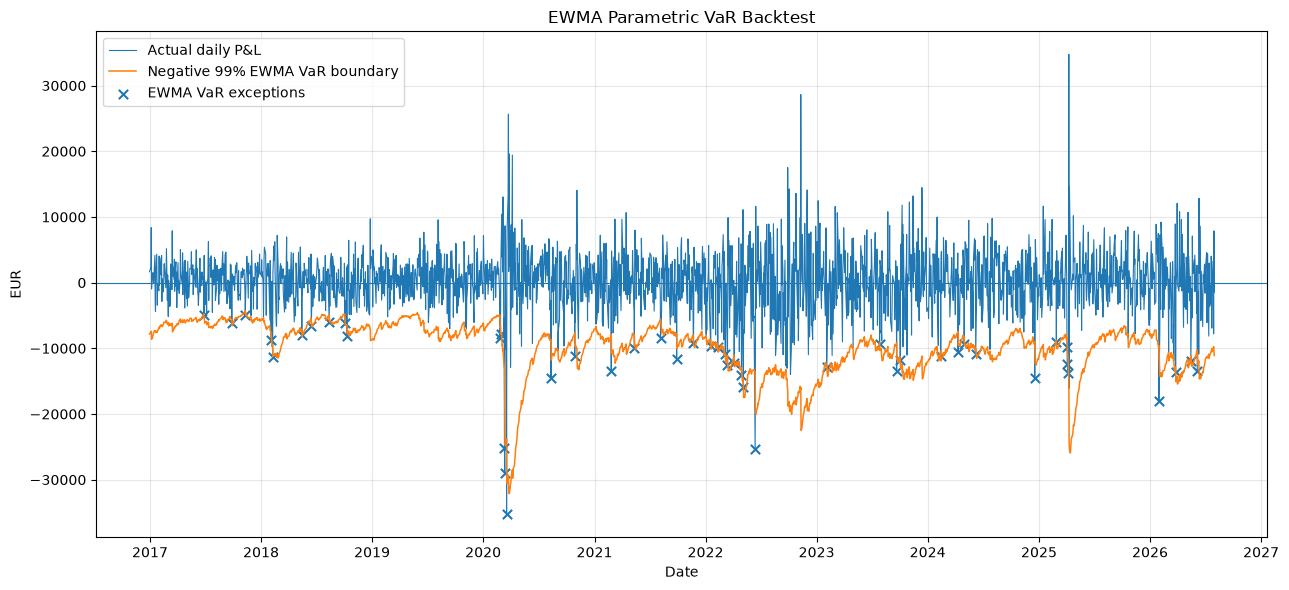

In [102]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    ewma_backtest_results.index,
    ewma_backtest_results[
        "actual_pnl_eur"
    ],
    linewidth=0.8,
    label="Actual daily P&L",
)

ax.plot(
    ewma_backtest_results.index,
    -ewma_backtest_results[
        "ewma_var_eur"
    ],
    linewidth=1.1,
    label="Negative 99% EWMA VaR boundary",
)

ewma_exception_dates = ewma_backtest_results[
    ewma_backtest_results[
        "ewma_exception"
    ]
]

ax.scatter(
    ewma_exception_dates.index,
    ewma_exception_dates[
        "actual_pnl_eur"
    ],
    marker="x",
    s=45,
    label="EWMA VaR exceptions",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "EWMA Parametric VaR Backtest"
)
ax.set_xlabel("Date")
ax.set_ylabel("EUR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [103]:
ewma_current_results.to_csv(
    TABLES_DIR / "ewma_current_var_es.csv",
    index=False,
)

ewma_backtest_results.to_csv(
    TABLES_DIR / "ewma_rolling_backtest.csv",
    index=True,
)

ewma_exception_summary.to_csv(
    TABLES_DIR / "ewma_exception_summary.csv",
    index=False,
)

fig.savefig(
    CHARTS_DIR / "ewma_var_backtest.png",
    dpi=300,
    bbox_inches="tight",
)

print("EWMA outputs saved.")

EWMA outputs saved.


### EWMA interpretation

The current 99% EWMA Parametric VaR is approximately EUR 10,774, with an
Expected Shortfall of approximately EUR 12,343.

The EWMA estimate is slightly higher than the ordinary Parametric Normal VaR
but remains materially below Historical Simulation VaR.

Across the rolling backtesting sample, the EWMA model produces 47 exceptions
against approximately 24 expected exceptions. Its observed exception rate is
1.96%, almost twice the theoretical 1% rate.

The EWMA model therefore does not automatically improve risk calibration.
Although it responds more quickly to recent volatility, it may underestimate
the initial movement into a stressed regime and subsequently reduce its risk
forecast rapidly as large observations receive progressively less weight.
Formal coverage and independence tests are required before reaching a final
conclusion.

### 2.2 EWMA coverage and independence tests

The EWMA exception sequence is evaluated using:

- Kupiec unconditional coverage
- Christoffersen exception independence
- Christoffersen conditional coverage

A model passes conditional coverage only when both its exception frequency
and the timing of its exceptions are consistent with the stated VaR level.

In [104]:
def kupiec_unconditional_coverage_test(
    exceptions: pd.Series,
    confidence_level: float,
) -> dict:
    """Perform the Kupiec unconditional-coverage test."""
    exception_values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
    )

    observations = len(exception_values)

    if observations == 0:
        raise ValueError("The exception series is empty.")

    actual_exceptions = int(exception_values.sum())
    expected_probability = 1 - confidence_level
    observed_probability = actual_exceptions / observations

    null_log_likelihood = (
        xlogy(actual_exceptions, expected_probability)
        + xlogy(
            observations - actual_exceptions,
            1 - expected_probability,
        )
    )

    alternative_log_likelihood = (
        xlogy(actual_exceptions, observed_probability)
        + xlogy(
            observations - actual_exceptions,
            1 - observed_probability,
        )
    )

    lr_statistic = -2 * (
        null_log_likelihood
        - alternative_log_likelihood
    )

    p_value = chi2.sf(lr_statistic, df=1)

    return {
        "observations": observations,
        "expected_exceptions": (
            observations * expected_probability
        ),
        "actual_exceptions": actual_exceptions,
        "expected_probability": expected_probability,
        "observed_probability": observed_probability,
        "kupiec_lr_statistic": lr_statistic,
        "kupiec_p_value": p_value,
        "reject_unconditional_coverage_at_5_percent": (
            p_value < 0.05
        ),
    }

In [105]:
def christoffersen_independence_test(
    exceptions: pd.Series,
) -> dict:
    """Test whether VaR exceptions occur independently."""
    values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
        .to_numpy()
    )

    if len(values) < 2:
        raise ValueError(
            "At least two observations are required."
        )

    previous = values[:-1]
    current = values[1:]

    n00 = int(
        ((previous == 0) & (current == 0)).sum()
    )
    n01 = int(
        ((previous == 0) & (current == 1)).sum()
    )
    n10 = int(
        ((previous == 1) & (current == 0)).sum()
    )
    n11 = int(
        ((previous == 1) & (current == 1)).sum()
    )

    total_transitions = n00 + n01 + n10 + n11
    total_exceptions = n01 + n11

    unconditional_probability = (
        total_exceptions / total_transitions
    )

    probability_after_no_exception = (
        n01 / (n00 + n01)
        if n00 + n01 > 0
        else 0.0
    )

    probability_after_exception = (
        n11 / (n10 + n11)
        if n10 + n11 > 0
        else 0.0
    )

    null_log_likelihood = (
        xlogy(
            n00 + n10,
            1 - unconditional_probability,
        )
        + xlogy(
            n01 + n11,
            unconditional_probability,
        )
    )

    alternative_log_likelihood = (
        xlogy(
            n00,
            1 - probability_after_no_exception,
        )
        + xlogy(
            n01,
            probability_after_no_exception,
        )
        + xlogy(
            n10,
            1 - probability_after_exception,
        )
        + xlogy(
            n11,
            probability_after_exception,
        )
    )

    lr_statistic = -2 * (
        null_log_likelihood
        - alternative_log_likelihood
    )

    p_value = chi2.sf(lr_statistic, df=1)

    return {
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
        "probability_after_no_exception": (
            probability_after_no_exception
        ),
        "probability_after_exception": (
            probability_after_exception
        ),
        "independence_lr_statistic": lr_statistic,
        "independence_p_value": p_value,
        "reject_independence_at_5_percent": (
            p_value < 0.05
        ),
    }

In [106]:
ewma_kupiec = kupiec_unconditional_coverage_test(
    exceptions=ewma_backtest_results[
        "ewma_exception"
    ],
    confidence_level=CONFIDENCE_LEVEL,
)

ewma_independence = (
    christoffersen_independence_test(
        exceptions=ewma_backtest_results[
            "ewma_exception"
        ]
    )
)

ewma_conditional_coverage_lr = (
    ewma_kupiec["kupiec_lr_statistic"]
    + ewma_independence[
        "independence_lr_statistic"
    ]
)

ewma_conditional_coverage_p_value = chi2.sf(
    ewma_conditional_coverage_lr,
    df=2,
)

ewma_test_results = pd.DataFrame(
    {
        "model": ["EWMA Parametric Normal"],
        "observations": [
            ewma_kupiec["observations"]
        ],
        "expected_exceptions": [
            ewma_kupiec["expected_exceptions"]
        ],
        "actual_exceptions": [
            ewma_kupiec["actual_exceptions"]
        ],
        "observed_exception_rate": [
            ewma_kupiec["observed_probability"]
        ],
        "kupiec_lr": [
            ewma_kupiec["kupiec_lr_statistic"]
        ],
        "kupiec_p_value": [
            ewma_kupiec["kupiec_p_value"]
        ],
        "probability_after_no_exception": [
            ewma_independence[
                "probability_after_no_exception"
            ]
        ],
        "probability_after_exception": [
            ewma_independence[
                "probability_after_exception"
            ]
        ],
        "independence_lr": [
            ewma_independence[
                "independence_lr_statistic"
            ]
        ],
        "independence_p_value": [
            ewma_independence[
                "independence_p_value"
            ]
        ],
        "conditional_coverage_lr": [
            ewma_conditional_coverage_lr
        ],
        "conditional_coverage_p_value": [
            ewma_conditional_coverage_p_value
        ],
        "reject_conditional_coverage_at_5_percent": [
            ewma_conditional_coverage_p_value < 0.05
        ],
    }
)

display(
    ewma_test_results.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.4f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.4f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,EWMA Parametric Normal,2404,24.04,47,1.96%,17.3225,0.0000,1.87%,6.38%,3.1280,0.0770,20.4504,0.000036,True


In [107]:
ewma_test_results.to_csv(
    TABLES_DIR / "ewma_backtesting_tests.csv",
    index=False,
)

print("EWMA statistical tests saved.")

EWMA statistical tests saved.


### EWMA backtesting interpretation

The EWMA model produces 47 exceptions across 2,404 forecasts, compared with
approximately 24 expected exceptions. The Kupiec p-value is below 0.0001, so
correct unconditional coverage is rejected.

The probability of an exception following a non-exception is approximately
1.87%, while the probability following another exception is approximately
6.38%. However, the Christoffersen independence-test p-value is 0.0770.
Exception independence is therefore not rejected at the 5% significance
level.

The combined conditional-coverage p-value is 0.000036, so conditional
coverage is rejected. This rejection is primarily driven by the model's
excessive exception frequency rather than statistically significant
exception clustering.

Compared with the original Historical Simulation and Parametric Normal
models, EWMA appears to improve the timing and independence of exceptions,
but it does not improve overall calibration.

## 3. Weighted Historical Simulation

Ordinary Historical Simulation gives every observation equal probability.

Weighted Historical Simulation instead applies exponentially declining
weights:

\[
w_i
=
\frac{(1-\lambda)\lambda^{T-i}}
{\sum_{j=1}^{T}(1-\lambda)\lambda^{T-j}},
\]

where the newest observation receives the largest weight.

The model preserves the empirical shape of the P&L distribution while
allowing recent market conditions to influence the risk estimate more
strongly.

A decay factor of 0.99 is used. This is higher than the EWMA covariance
decay factor because the weights are applied directly to historical
scenarios rather than to the covariance matrix.

In [108]:
WHS_LAMBDA = 0.99

print(f"Weighted Historical Simulation lambda: {WHS_LAMBDA}")

Weighted Historical Simulation lambda: 0.99


In [109]:
def calculate_weighted_historical_var_es(
    pnl_series: pd.Series,
    confidence_level: float,
    decay_factor: float = 0.99,
) -> dict:
    """
    Calculate exponentially weighted Historical VaR and Expected Shortfall.
    """
    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must lie between zero and one."
        )

    if not 0 < decay_factor < 1:
        raise ValueError(
            "decay_factor must lie between zero and one."
        )

    clean_pnl = pd.Series(
        pnl_series
    ).dropna().astype(float)

    if clean_pnl.empty:
        raise ValueError("pnl_series cannot be empty.")

    observations = len(clean_pnl)
    tail_probability = 1 - confidence_level

    # Newest observation receives the largest weight.
    powers = np.arange(
        observations - 1,
        -1,
        -1,
    )

    weights = (
        (1 - decay_factor)
        * decay_factor**powers
    )

    weights = weights / weights.sum()

    weighted_data = pd.DataFrame(
        {
            "pnl_eur": clean_pnl.to_numpy(),
            "weight": weights,
        },
        index=clean_pnl.index,
    )

    # Sort from worst P&L to best P&L.
    weighted_data = weighted_data.sort_values(
        "pnl_eur",
        ascending=True,
    )

    weighted_data["cumulative_weight"] = (
        weighted_data["weight"].cumsum()
    )

    cumulative_weights = weighted_data[
        "cumulative_weight"
    ].to_numpy()

    boundary_position = int(
        np.searchsorted(
            cumulative_weights,
            tail_probability,
            side="left",
        )
    )

    if boundary_position >= len(weighted_data):
        raise RuntimeError(
            "Unable to identify the weighted VaR boundary."
        )

    pnl_quantile = float(
        weighted_data.iloc[
            boundary_position
        ]["pnl_eur"]
    )

    var_eur = -pnl_quantile

    # Cumulative probability immediately before each scenario.
    cumulative_weight_before = (
        weighted_data["cumulative_weight"]
        - weighted_data["weight"]
    ).to_numpy()

    scenario_weights = weighted_data[
        "weight"
    ].to_numpy()

    # Allocate exactly the worst 1% probability mass.
    allocated_tail_weights = np.clip(
        tail_probability
        - cumulative_weight_before,
        0.0,
        scenario_weights,
    )

    allocated_tail_probability = (
        allocated_tail_weights.sum()
    )

    if not np.isclose(
        allocated_tail_probability,
        tail_probability,
        atol=1e-12,
    ):
        raise RuntimeError(
            "The allocated ES tail probability is incorrect."
        )

    weighted_tail_pnl = np.sum(
        weighted_data["pnl_eur"].to_numpy()
        * allocated_tail_weights
    )

    expected_shortfall_eur = -(
        weighted_tail_pnl
        / allocated_tail_probability
    )

    # Allow only an extremely small numerical tolerance.
    if expected_shortfall_eur < var_eur - 1e-8:
        raise RuntimeError(
            "Expected Shortfall is materially below VaR."
        )

    tail_scenarios_used = int(
        (allocated_tail_weights > 0).sum()
    )

    return {
        "confidence_level": confidence_level,
        "decay_factor": decay_factor,
        "observations": observations,
        "effective_tail_probability": tail_probability,
        "var_eur": var_eur,
        "expected_shortfall_eur": expected_shortfall_eur,
        "tail_scenarios_used": tail_scenarios_used,
        "newest_observation_weight": weights[-1],
        "oldest_observation_weight": weights[0],
    }

In [110]:
recent_portfolio_pnl = portfolio_pnl.iloc[
    -LOOKBACK_WINDOW:
]

whs_current = calculate_weighted_historical_var_es(
    pnl_series=recent_portfolio_pnl,
    confidence_level=CONFIDENCE_LEVEL,
    decay_factor=WHS_LAMBDA,
)

whs_current_results = pd.DataFrame(
    {
        "model": ["Weighted Historical Simulation"],
        **{
            key: [value]
            for key, value in whs_current.items()
        },
    }
)

assert (
    whs_current_results.loc[
        0,
        "expected_shortfall_eur",
    ]
    >= whs_current_results.loc[0, "var_eur"]
)

display(
    whs_current_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "decay_factor": "{:.3f}",
            "effective_tail_probability": "{:.2%}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
            "newest_observation_weight": "{:.4%}",
            "oldest_observation_weight": "{:.4%}",
        }
    )
)

,model,confidence_level,decay_factor,observations,effective_tail_probability,var_eur,expected_shortfall_eur,tail_scenarios_used,newest_observation_weight,oldest_observation_weight
0,Weighted Historical Simulation,99%,0.990,250,1.00%,"EUR 13,422.25","EUR 14,905.66",3,1.0882%,0.0891%


In [111]:
current_model_comparison = pd.DataFrame(
    {
        "model": [
            "Historical Simulation",
            "Parametric Normal",
            "EWMA Parametric Normal",
            "Weighted Historical Simulation",
        ],
        "var_eur": [
            12_669.90,
            10_698.74,
            ewma_var_eur,
            whs_current["var_eur"],
        ],
        "expected_shortfall_eur": [
            14_999.77,
            12_257.16,
            ewma_es_eur,
            whs_current["expected_shortfall_eur"],
        ],
    }
)

display(
    current_model_comparison.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,var_eur,expected_shortfall_eur
0,Historical Simulation,"EUR 12,669.90","EUR 14,999.77"
1,Parametric Normal,"EUR 10,698.74","EUR 12,257.16"
2,EWMA Parametric Normal,"EUR 10,773.87","EUR 12,343.24"
3,Weighted Historical Simulation,"EUR 13,422.25","EUR 14,905.66"


### 3.1 Rolling Weighted Historical Simulation backtest

For every forecast date, the preceding 250 portfolio P&L observations are
used.

The observations retain their realised values, but the most recent scenario
receives the largest probability weight. The actual P&L on the forecast date
is not included in the estimation window, preventing look-ahead bias.

In [112]:
rolling_whs_records = []

for observation_number in range(
    LOOKBACK_WINDOW,
    len(portfolio_pnl),
):
    forecast_date = portfolio_pnl.index[
        observation_number
    ]

    estimation_sample = portfolio_pnl.iloc[
        observation_number - LOOKBACK_WINDOW:
        observation_number
    ]

    forecast_result = (
        calculate_weighted_historical_var_es(
            pnl_series=estimation_sample,
            confidence_level=CONFIDENCE_LEVEL,
            decay_factor=WHS_LAMBDA,
        )
    )

    actual_pnl = float(
        portfolio_pnl.iloc[observation_number]
    )

    forecast_var = float(
        forecast_result["var_eur"]
    )

    exception = actual_pnl < -forecast_var

    rolling_whs_records.append(
        {
            "date": forecast_date,
            "actual_pnl_eur": actual_pnl,
            "whs_var_eur": forecast_var,
            "whs_es_eur": forecast_result[
                "expected_shortfall_eur"
            ],
            "whs_exception": exception,
        }
    )

whs_backtest_results = (
    pd.DataFrame(rolling_whs_records)
    .set_index("date")
)

assert (
    len(whs_backtest_results)
    == len(portfolio_pnl) - LOOKBACK_WINDOW
)

assert (
    whs_backtest_results["whs_var_eur"] > 0
).all()

assert np.all(
    whs_backtest_results["whs_es_eur"]
    >= whs_backtest_results["whs_var_eur"] - 1e-8
)

print(
    f"Weighted Historical forecasts: "
    f"{len(whs_backtest_results):,}"
)

display(whs_backtest_results.head())

Weighted Historical forecasts: 2,404


,actual_pnl_eur,whs_var_eur,whs_es_eur,whs_exception
date,,,,
2016-12-30,1654.611656,10777.18058,11076.040781,False
2017-01-03,2194.106621,10777.18058,11073.052179,False
2017-01-04,2403.266442,10777.18058,11070.093463,False
2017-01-05,8378.931018,10777.18058,11067.164334,False
2017-01-06,-965.687886,10777.18058,11064.264496,False


In [113]:
whs_observations = len(whs_backtest_results)

whs_actual_exceptions = int(
    whs_backtest_results[
        "whs_exception"
    ].sum()
)

whs_exception_summary = pd.DataFrame(
    {
        "model": [
            "Weighted Historical Simulation"
        ],
        "observations": [
            whs_observations
        ],
        "expected_exceptions": [
            whs_observations
            * TAIL_PROBABILITY
        ],
        "actual_exceptions": [
            whs_actual_exceptions
        ],
        "expected_exception_rate": [
            TAIL_PROBABILITY
        ],
        "actual_exception_rate": [
            whs_actual_exceptions
            / whs_observations
        ],
    }
)

whs_exception_summary[
    "exception_difference"
] = (
    whs_exception_summary["actual_exceptions"]
    - whs_exception_summary["expected_exceptions"]
)

display(
    whs_exception_summary.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_exception_rate": "{:.2%}",
            "actual_exception_rate": "{:.2%}",
            "exception_difference": "{:+.2f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_exception_rate,actual_exception_rate,exception_difference
0,Weighted Historical Simulation,2404,24.04,35,1.00%,1.46%,+10.96


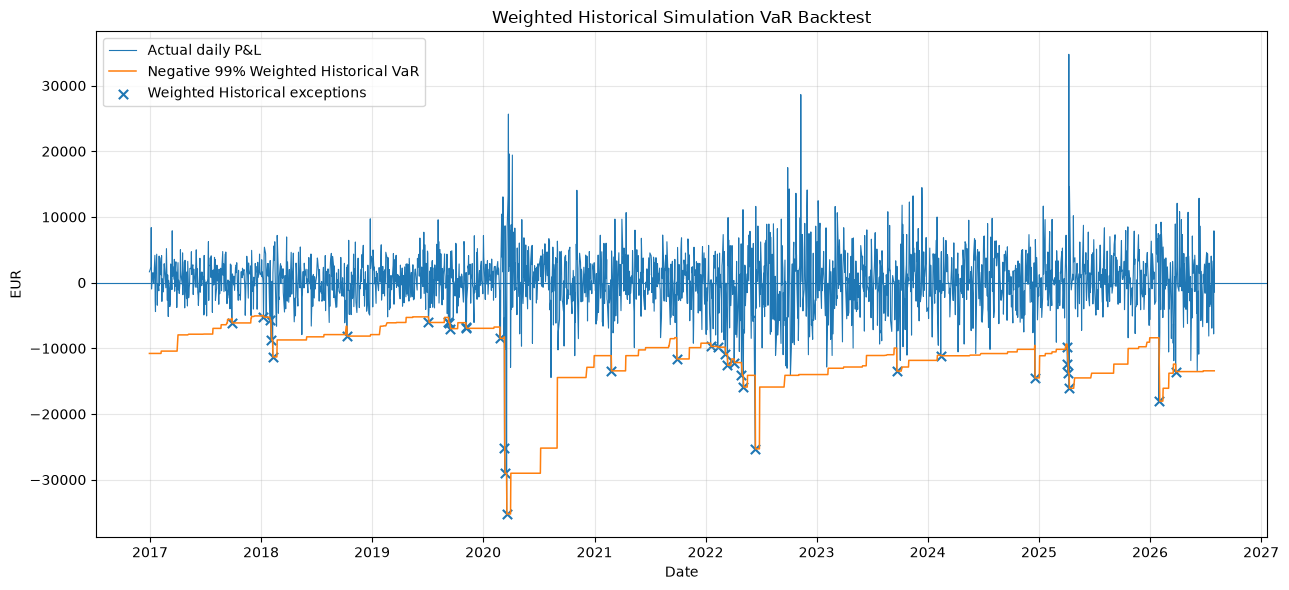

In [114]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    whs_backtest_results.index,
    whs_backtest_results["actual_pnl_eur"],
    linewidth=0.8,
    label="Actual daily P&L",
)

ax.plot(
    whs_backtest_results.index,
    -whs_backtest_results["whs_var_eur"],
    linewidth=1.1,
    label="Negative 99% Weighted Historical VaR",
)

whs_exception_dates = whs_backtest_results[
    whs_backtest_results["whs_exception"]
]

ax.scatter(
    whs_exception_dates.index,
    whs_exception_dates["actual_pnl_eur"],
    marker="x",
    s=45,
    label="Weighted Historical exceptions",
)

ax.axhline(0, linewidth=0.8)

ax.set_title(
    "Weighted Historical Simulation VaR Backtest"
)
ax.set_xlabel("Date")
ax.set_ylabel("EUR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
whs_current_results.to_csv(
    TABLES_DIR / "weighted_historical_current_var_es.csv",
    index=False,
)

whs_backtest_results.to_csv(
    TABLES_DIR / "weighted_historical_backtest.csv",
    index=True,
)

whs_exception_summary.to_csv(
    TABLES_DIR / "weighted_historical_exception_summary.csv",
    index=False,
)

fig.savefig(
    CHARTS_DIR / "weighted_historical_var_backtest.png",
    dpi=300,
    bbox_inches="tight",
)

print("Weighted Historical Simulation outputs saved.")

Weighted Historical Simulation outputs saved.


### Weighted Historical Simulation interpretation

The current 99% Weighted Historical Simulation VaR is approximately
EUR 13,422, the highest current VaR estimate among the four models.
Its Expected Shortfall is approximately EUR 14,906.

The most recent observation receives a weight of approximately 1.09%, while
the oldest observation in the 250-day window receives a weight of only
approximately 0.09%. The model therefore reacts more strongly to recent
market conditions than ordinary Historical Simulation.

Across 2,404 rolling forecasts, the model produces 35 exceptions, corresponding
to an exception rate of 1.46%. This is the lowest exception rate among the
models considered so far, although it remains above the theoretical 1% rate.

Weighted Historical Simulation therefore appears to improve calibration,
but formal coverage and independence tests are still required.

In [116]:
whs_kupiec = kupiec_unconditional_coverage_test(
    exceptions=whs_backtest_results["whs_exception"],
    confidence_level=CONFIDENCE_LEVEL,
)

whs_independence = christoffersen_independence_test(
    exceptions=whs_backtest_results["whs_exception"],
)

whs_conditional_coverage_lr = (
    whs_kupiec["kupiec_lr_statistic"]
    + whs_independence["independence_lr_statistic"]
)

whs_conditional_coverage_p_value = chi2.sf(
    whs_conditional_coverage_lr,
    df=2,
)

whs_test_results = pd.DataFrame(
    {
        "model": ["Weighted Historical Simulation"],
        "observations": [
            whs_kupiec["observations"]
        ],
        "expected_exceptions": [
            whs_kupiec["expected_exceptions"]
        ],
        "actual_exceptions": [
            whs_kupiec["actual_exceptions"]
        ],
        "observed_exception_rate": [
            whs_kupiec["observed_probability"]
        ],
        "kupiec_lr": [
            whs_kupiec["kupiec_lr_statistic"]
        ],
        "kupiec_p_value": [
            whs_kupiec["kupiec_p_value"]
        ],
        "probability_after_no_exception": [
            whs_independence[
                "probability_after_no_exception"
            ]
        ],
        "probability_after_exception": [
            whs_independence[
                "probability_after_exception"
            ]
        ],
        "independence_lr": [
            whs_independence[
                "independence_lr_statistic"
            ]
        ],
        "independence_p_value": [
            whs_independence[
                "independence_p_value"
            ]
        ],
        "conditional_coverage_lr": [
            whs_conditional_coverage_lr
        ],
        "conditional_coverage_p_value": [
            whs_conditional_coverage_p_value
        ],
        "reject_conditional_coverage_at_5_percent": [
            whs_conditional_coverage_p_value < 0.05
        ],
    }
)

display(
    whs_test_results.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.4f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.4f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,Weighted Historical Simulation,2404,24.04,35,1.46%,4.4246,0.0354,1.31%,11.43%,10.2368,0.0014,14.6614,0.000655,True


In [117]:
whs_test_results.to_csv(
    TABLES_DIR / "weighted_historical_backtesting_tests.csv",
    index=False,
)

print("Weighted Historical Simulation statistical tests saved.")

Weighted Historical Simulation statistical tests saved.


### Weighted Historical Simulation backtesting interpretation

Weighted Historical Simulation produces 35 exceptions across 2,404 forecasts,
compared with approximately 24 expected exceptions.

Its Kupiec p-value is 0.0354, so correct unconditional coverage is narrowly
rejected at the 5% significance level. Although it produces fewer exceptions
than the other models, its observed exception rate of 1.46% remains
statistically inconsistent with a correctly calibrated 99% VaR model.

The probability of an exception following a non-exception is approximately
1.31%, while the probability following another exception rises to
approximately 11.43%. The Christoffersen independence-test p-value is 0.0014,
so exception independence is rejected.

The combined conditional-coverage p-value is 0.000655. Weighted Historical
Simulation therefore fails conditional coverage because it produces both too
many exceptions and significant exception clustering.

The model performs best in terms of total exception count, but this does not
make it statistically adequate.

## 4. Monte Carlo VaR and Expected Shortfall

Monte Carlo simulation generates a large number of hypothetical correlated
daily risk-factor returns.

The simulated portfolio P&L for scenario \(s\) is:

\[
P\&L_s = \mathbf{N}^{\top}\mathbf{r}_s,
\]

where \(\mathbf{N}\) contains the portfolio notionals and
\(\mathbf{r}_s\) is a simulated vector of correlated risk-factor returns.

The initial Monte Carlo model assumes:

- Multivariate normally distributed returns
- Zero expected daily return
- A covariance matrix estimated from the preceding 250 observations
- Fixed linear portfolio exposures

Under these assumptions, Monte Carlo VaR should converge toward Parametric
Normal VaR as the number of simulations increases.

In [118]:
def calculate_monte_carlo_var_es(
    return_data: pd.DataFrame,
    notionals: pd.Series,
    confidence_level: float,
    simulations: int = 100_000,
    random_seed: int = 42,
) -> tuple[dict, np.ndarray]:
    """
    Calculate multivariate Normal Monte Carlo VaR and Expected Shortfall.

    Parameters
    ----------
    return_data:
        Historical risk-factor returns used to estimate covariance.
    notionals:
        Portfolio notionals aligned with the return columns.
    confidence_level:
        VaR confidence level, such as 0.99.
    simulations:
        Number of simulated one-day scenarios.
    random_seed:
        Seed used to make results reproducible.

    Returns
    -------
    tuple
        Result dictionary and array of simulated portfolio P&Ls.
    """
    if return_data.empty:
        raise ValueError("return_data cannot be empty.")

    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must lie between zero and one."
        )

    if simulations < 1_000:
        raise ValueError(
            "Use at least 1,000 Monte Carlo simulations."
        )

    aligned_notionals = notionals.reindex(
        return_data.columns
    )

    if aligned_notionals.isna().any():
        raise ValueError(
            "Notionals are not aligned with return columns."
        )

    covariance_matrix = (
        return_data
        .cov()
        .to_numpy(dtype=float)
    )

    mean_vector = np.zeros(
        return_data.shape[1],
        dtype=float,
    )

    rng = np.random.default_rng(random_seed)

    simulated_returns = rng.multivariate_normal(
        mean=mean_vector,
        cov=covariance_matrix,
        size=simulations,
        check_valid="raise",
    )

    simulated_portfolio_pnl = (
        simulated_returns
        @ aligned_notionals.to_numpy(dtype=float)
    )

    tail_probability = 1 - confidence_level

    pnl_quantile = np.quantile(
        simulated_portfolio_pnl,
        tail_probability,
        method="linear",
    )

    var_eur = -float(pnl_quantile)

    tail_pnl = simulated_portfolio_pnl[
        simulated_portfolio_pnl <= pnl_quantile
    ]

    expected_shortfall_eur = -float(
        tail_pnl.mean()
    )

    return (
        {
            "confidence_level": confidence_level,
            "observations": len(return_data),
            "simulations": simulations,
            "random_seed": random_seed,
            "portfolio_volatility_eur": float(
                simulated_portfolio_pnl.std(ddof=1)
            ),
            "var_eur": var_eur,
            "expected_shortfall_eur": (
                expected_shortfall_eur
            ),
            "tail_simulations": len(tail_pnl),
        },
        simulated_portfolio_pnl,
    )

In [119]:
mc_current, simulated_portfolio_pnl = (
    calculate_monte_carlo_var_es(
        return_data=returns.iloc[-LOOKBACK_WINDOW:],
        notionals=NOTIONALS,
        confidence_level=CONFIDENCE_LEVEL,
        simulations=MONTE_CARLO_SIMULATIONS,
        random_seed=RANDOM_SEED,
    )
)

mc_current_results = pd.DataFrame(
    {
        "model": ["Monte Carlo Normal"],
        **{
            key: [value]
            for key, value in mc_current.items()
        },
    }
)

assert (
    mc_current["expected_shortfall_eur"]
    >= mc_current["var_eur"]
)

display(
    mc_current_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "portfolio_volatility_eur": "EUR {:,.2f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,confidence_level,observations,simulations,random_seed,portfolio_volatility_eur,var_eur,expected_shortfall_eur,tail_simulations
0,Monte Carlo Normal,99%,250,100000,42,"EUR 4,604.57","EUR 10,678.74","EUR 12,301.69",1000


In [120]:
current_model_comparison = pd.DataFrame(
    {
        "model": [
            "Historical Simulation",
            "Parametric Normal",
            "EWMA Parametric Normal",
            "Weighted Historical Simulation",
            "Monte Carlo Normal",
        ],
        "var_eur": [
            12_669.90,
            10_698.74,
            ewma_var_eur,
            whs_current["var_eur"],
            mc_current["var_eur"],
        ],
        "expected_shortfall_eur": [
            14_999.77,
            12_257.16,
            ewma_es_eur,
            whs_current["expected_shortfall_eur"],
            mc_current["expected_shortfall_eur"],
        ],
    }
)

display(
    current_model_comparison.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,var_eur,expected_shortfall_eur
0,Historical Simulation,"EUR 12,669.90","EUR 14,999.77"
1,Parametric Normal,"EUR 10,698.74","EUR 12,257.16"
2,EWMA Parametric Normal,"EUR 10,773.87","EUR 12,343.24"
3,Weighted Historical Simulation,"EUR 13,422.25","EUR 14,905.66"
4,Monte Carlo Normal,"EUR 10,678.74","EUR 12,301.69"


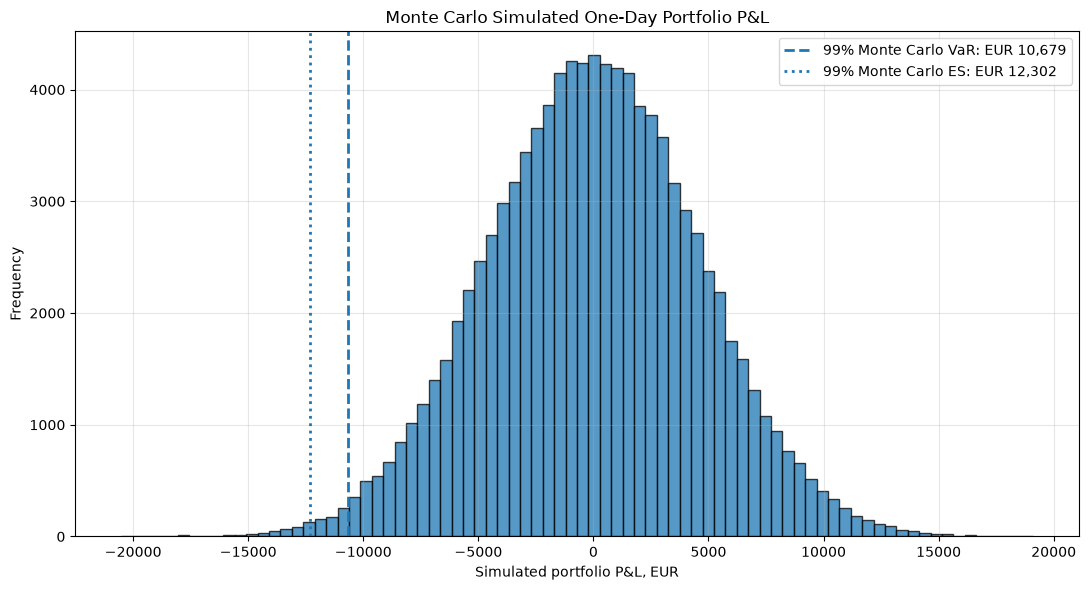

In [121]:
mc_var_eur = mc_current["var_eur"]
mc_es_eur = mc_current["expected_shortfall_eur"]

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    simulated_portfolio_pnl,
    bins=80,
    edgecolor="black",
    alpha=0.75,
)

ax.axvline(
    -mc_var_eur,
    linestyle="--",
    linewidth=2,
    label=f"99% Monte Carlo VaR: EUR {mc_var_eur:,.0f}",
)

ax.axvline(
    -mc_es_eur,
    linestyle=":",
    linewidth=2,
    label=f"99% Monte Carlo ES: EUR {mc_es_eur:,.0f}",
)

ax.set_title(
    "Monte Carlo Simulated One-Day Portfolio P&L"
)
ax.set_xlabel("Simulated portfolio P&L, EUR")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Rolling Monte Carlo backtest

For each forecast date, the preceding 250 risk-factor returns are used to
estimate the covariance matrix and portfolio volatility.

A common set of simulated standard-normal shocks is scaled by the forecast
portfolio volatility. Using common random numbers reduces unnecessary
simulation noise when comparing forecasts through time.

For this linear normally distributed portfolio, this efficient implementation
is mathematically equivalent to simulating the full multivariate return vector
and then aggregating portfolio P&L.

In [122]:
ROLLING_MC_SIMULATIONS = 100_000

rolling_mc_rng = np.random.default_rng(
    RANDOM_SEED
)

standard_normal_scenarios = (
    rolling_mc_rng.standard_normal(
        ROLLING_MC_SIMULATIONS
    )
)

standard_mc_quantile = np.quantile(
    standard_normal_scenarios,
    TAIL_PROBABILITY,
    method="linear",
)

standard_mc_var_multiplier = (
    -standard_mc_quantile
)

standard_mc_tail = standard_normal_scenarios[
    standard_normal_scenarios
    <= standard_mc_quantile
]

standard_mc_es_multiplier = (
    -standard_mc_tail.mean()
)

print(
    f"Monte Carlo VaR multiplier: "
    f"{standard_mc_var_multiplier:.4f}"
)

print(
    f"Monte Carlo ES multiplier: "
    f"{standard_mc_es_multiplier:.4f}"
)

print(
    f"Analytical Normal VaR multiplier: "
    f"{norm.ppf(CONFIDENCE_LEVEL):.4f}"
)

Monte Carlo VaR multiplier: 2.3435
Monte Carlo ES multiplier: 2.6875
Analytical Normal VaR multiplier: 2.3263


In [123]:
rolling_mc_records = []

notional_vector = NOTIONALS.reindex(
    returns.columns
).to_numpy(dtype=float)

for observation_number in range(
    LOOKBACK_WINDOW,
    len(returns),
):
    forecast_date = returns.index[
        observation_number
    ]

    estimation_returns = returns.iloc[
        observation_number - LOOKBACK_WINDOW:
        observation_number
    ]

    covariance_matrix = (
        estimation_returns
        .cov()
        .to_numpy(dtype=float)
    )

    portfolio_variance = float(
        notional_vector
        @ covariance_matrix
        @ notional_vector
    )

    portfolio_variance = max(
        portfolio_variance,
        0.0,
    )

    portfolio_volatility = np.sqrt(
        portfolio_variance
    )

    forecast_var = (
        standard_mc_var_multiplier
        * portfolio_volatility
    )

    forecast_es = (
        standard_mc_es_multiplier
        * portfolio_volatility
    )

    actual_pnl = float(
        portfolio_pnl.iloc[
            observation_number
        ]
    )

    exception = actual_pnl < -forecast_var

    rolling_mc_records.append(
        {
            "date": forecast_date,
            "actual_pnl_eur": actual_pnl,
            "mc_volatility_eur": portfolio_volatility,
            "mc_var_eur": forecast_var,
            "mc_es_eur": forecast_es,
            "mc_exception": exception,
        }
    )

mc_backtest_results = (
    pd.DataFrame(rolling_mc_records)
    .set_index("date")
)

assert (
    len(mc_backtest_results)
    == len(returns) - LOOKBACK_WINDOW
)

assert (
    mc_backtest_results["mc_var_eur"] > 0
).all()

assert (
    mc_backtest_results["mc_es_eur"]
    >= mc_backtest_results["mc_var_eur"]
).all()

display(mc_backtest_results.head())

,actual_pnl_eur,mc_volatility_eur,mc_var_eur,mc_es_eur,mc_exception
date,,,,,
2016-12-30,1654.611656,3356.316722,7865.566794,9020.119085,False
2017-01-03,2194.106621,3356.988379,7867.140830,9021.924167,False
2017-01-04,2403.266442,3358.102924,7869.752780,9024.919513,False
2017-01-05,8378.931018,3355.523833,7863.708650,9017.988192,False
2017-01-06,-965.687886,3395.002692,7956.227809,9124.087835,False


In [124]:
mc_observations = len(mc_backtest_results)

mc_actual_exceptions = int(
    mc_backtest_results[
        "mc_exception"
    ].sum()
)

mc_exception_summary = pd.DataFrame(
    {
        "model": ["Monte Carlo Normal"],
        "observations": [mc_observations],
        "expected_exceptions": [
            mc_observations
            * TAIL_PROBABILITY
        ],
        "actual_exceptions": [
            mc_actual_exceptions
        ],
        "expected_exception_rate": [
            TAIL_PROBABILITY
        ],
        "actual_exception_rate": [
            mc_actual_exceptions
            / mc_observations
        ],
    }
)

mc_exception_summary[
    "exception_difference"
] = (
    mc_exception_summary["actual_exceptions"]
    - mc_exception_summary["expected_exceptions"]
)

display(
    mc_exception_summary.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_exception_rate": "{:.2%}",
            "actual_exception_rate": "{:.2%}",
            "exception_difference": "{:+.2f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_exception_rate,actual_exception_rate,exception_difference
0,Monte Carlo Normal,2404,24.04,45,1.00%,1.87%,+20.96


In [125]:
mc_current_results.to_csv(
    TABLES_DIR / "monte_carlo_current_var_es.csv",
    index=False,
)

mc_backtest_results.to_csv(
    TABLES_DIR / "monte_carlo_rolling_backtest.csv",
    index=True,
)

mc_exception_summary.to_csv(
    TABLES_DIR / "monte_carlo_exception_summary.csv",
    index=False,
)

fig.savefig(
    CHARTS_DIR / "monte_carlo_pnl_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

print("Monte Carlo outputs saved.")

Monte Carlo outputs saved.


### Monte Carlo interpretation

The current 99% Monte Carlo VaR is approximately EUR 10,679, while
Monte Carlo Expected Shortfall is approximately EUR 12,302.

These estimates are very close to the analytical Parametric Normal results.
This is expected because both models use the same normal-distribution,
covariance and linear-portfolio assumptions.

Across the rolling backtest, Monte Carlo VaR produces 45 exceptions,
corresponding to an observed exception rate of 1.87%. This is almost identical
to the Parametric Normal result.

Monte Carlo simulation therefore does not improve model calibration in this
setting. Its main advantage will emerge when nonlinear instruments, complex
payoffs or non-normal return distributions are introduced.

In [126]:
mc_kupiec = kupiec_unconditional_coverage_test(
    exceptions=mc_backtest_results["mc_exception"],
    confidence_level=CONFIDENCE_LEVEL,
)

mc_independence = christoffersen_independence_test(
    exceptions=mc_backtest_results["mc_exception"],
)

mc_conditional_coverage_lr = (
    mc_kupiec["kupiec_lr_statistic"]
    + mc_independence["independence_lr_statistic"]
)

mc_conditional_coverage_p_value = chi2.sf(
    mc_conditional_coverage_lr,
    df=2,
)

mc_test_results = pd.DataFrame(
    {
        "model": ["Monte Carlo Normal"],
        "observations": [
            mc_kupiec["observations"]
        ],
        "expected_exceptions": [
            mc_kupiec["expected_exceptions"]
        ],
        "actual_exceptions": [
            mc_kupiec["actual_exceptions"]
        ],
        "observed_exception_rate": [
            mc_kupiec["observed_probability"]
        ],
        "kupiec_lr": [
            mc_kupiec["kupiec_lr_statistic"]
        ],
        "kupiec_p_value": [
            mc_kupiec["kupiec_p_value"]
        ],
        "probability_after_no_exception": [
            mc_independence[
                "probability_after_no_exception"
            ]
        ],
        "probability_after_exception": [
            mc_independence[
                "probability_after_exception"
            ]
        ],
        "independence_lr": [
            mc_independence[
                "independence_lr_statistic"
            ]
        ],
        "independence_p_value": [
            mc_independence[
                "independence_p_value"
            ]
        ],
        "conditional_coverage_lr": [
            mc_conditional_coverage_lr
        ],
        "conditional_coverage_p_value": [
            mc_conditional_coverage_p_value
        ],
        "reject_conditional_coverage_at_5_percent": [
            mc_conditional_coverage_p_value < 0.05
        ],
    }
)

display(
    mc_test_results.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.6f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

mc_test_results.to_csv(
    TABLES_DIR / "monte_carlo_backtesting_tests.csv",
    index=False,
)

print("Monte Carlo statistical tests saved.")

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,Monte Carlo Normal,2404,24.04,45,1.87%,14.6900,0.000127,1.70%,11.11%,10.3073,0.001325,24.9974,0.000004,True


Monte Carlo statistical tests saved.


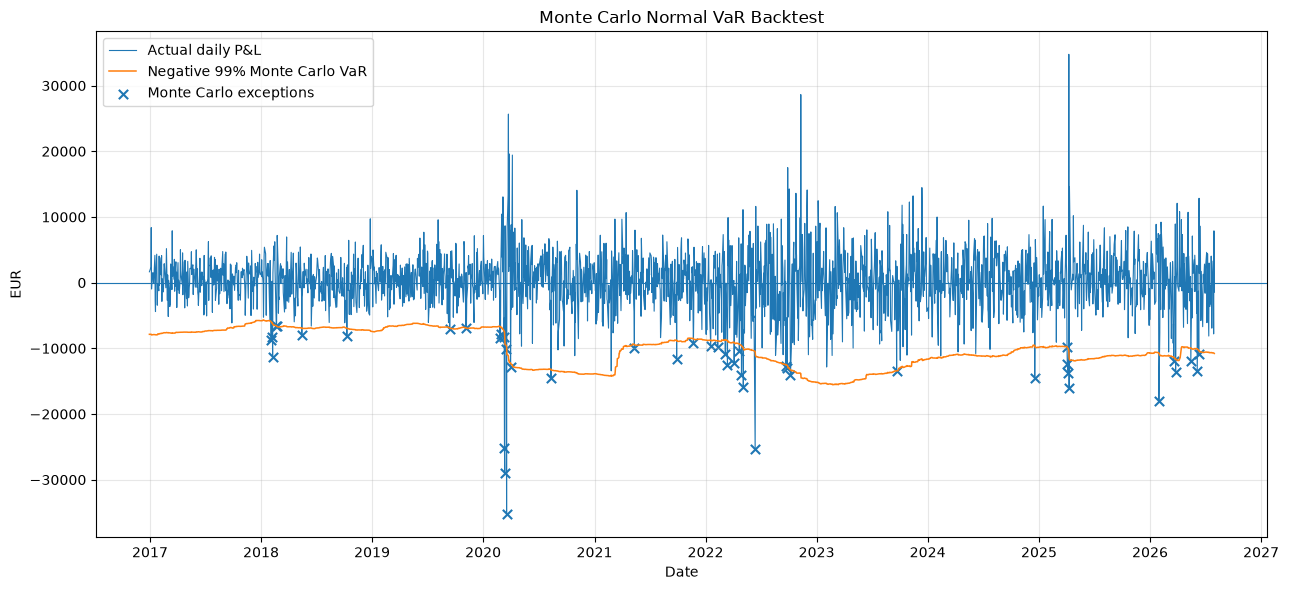

In [127]:
fig_mc_backtest, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    mc_backtest_results.index,
    mc_backtest_results["actual_pnl_eur"],
    linewidth=0.8,
    label="Actual daily P&L",
)

ax.plot(
    mc_backtest_results.index,
    -mc_backtest_results["mc_var_eur"],
    linewidth=1.1,
    label="Negative 99% Monte Carlo VaR",
)

mc_exception_dates = mc_backtest_results[
    mc_backtest_results["mc_exception"]
]

ax.scatter(
    mc_exception_dates.index,
    mc_exception_dates["actual_pnl_eur"],
    marker="x",
    s=45,
    label="Monte Carlo exceptions",
)

ax.axhline(0, linewidth=0.8)

ax.set_title("Monte Carlo Normal VaR Backtest")
ax.set_xlabel("Date")
ax.set_ylabel("EUR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig_mc_backtest.savefig(
    CHARTS_DIR / "monte_carlo_var_backtest.png",
    dpi=300,
    bbox_inches="tight",
)

### Monte Carlo backtesting interpretation

Monte Carlo Normal VaR produces 45 exceptions across 2,404 forecasts,
corresponding to an observed exception rate of 1.87%.

The Kupiec p-value is 0.000127, so correct unconditional coverage is rejected.
The probability of an exception increases from approximately 1.70% following
a non-exception to approximately 11.11% following another exception. The
Christoffersen independence-test p-value is 0.001325, so exception
independence is also rejected.

The combined conditional-coverage p-value is approximately 0.000004.
Monte Carlo Normal VaR therefore fails conditional coverage.

Its results closely resemble Parametric Normal VaR because both models use
normal returns, the same rolling covariance estimate and fixed linear
portfolio exposures.

In [128]:
day_1_kupiec = pd.read_csv(
    TABLES_DIR / "kupiec_test_results.csv"
)

day_1_independence = pd.read_csv(
    TABLES_DIR / "christoffersen_independence_results.csv"
)

day_1_conditional = pd.read_csv(
    TABLES_DIR / "conditional_coverage_results.csv"
)

day_1_validation = (
    day_1_kupiec[
        [
            "model",
            "observations",
            "expected_exceptions",
            "actual_exceptions",
            "observed_probability",
            "kupiec_lr_statistic",
            "kupiec_p_value",
        ]
    ]
    .rename(
        columns={
            "observed_probability": "observed_exception_rate",
            "kupiec_lr_statistic": "kupiec_lr",
        }
    )
    .merge(
        day_1_independence[
            [
                "model",
                "probability_after_no_exception",
                "probability_after_exception",
                "christoffersen_independence_lr",
                "christoffersen_independence_p_value",
            ]
        ].rename(
            columns={
                "christoffersen_independence_lr": "independence_lr",
                "christoffersen_independence_p_value": "independence_p_value",
            }
        ),
        on="model",
        how="inner",
    )
    .merge(
        day_1_conditional[
            [
                "model",
                "conditional_coverage_lr",
                "conditional_coverage_p_value",
                "reject_conditional_coverage_at_5_percent",
            ]
        ],
        on="model",
        how="inner",
    )
)

display(day_1_validation)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,Historical Simulation,2404,24.04,41,0.017055,9.977090,0.001585,0.015665,0.097561,7.908745,0.004920,17.885836,0.000131,True
1,Parametric Normal,2404,24.04,46,0.019135,15.984102,0.000064,0.017395,0.108696,9.910964,0.001643,25.895066,0.000002,True


In [129]:
day_2_validation = pd.concat(
    [
        ewma_test_results,
        whs_test_results,
        mc_test_results,
    ],
    ignore_index=True,
)

validation_columns = [
    "model",
    "observations",
    "expected_exceptions",
    "actual_exceptions",
    "observed_exception_rate",
    "kupiec_lr",
    "kupiec_p_value",
    "probability_after_no_exception",
    "probability_after_exception",
    "independence_lr",
    "independence_p_value",
    "conditional_coverage_lr",
    "conditional_coverage_p_value",
    "reject_conditional_coverage_at_5_percent",
]

all_model_validation = pd.concat(
    [
        day_1_validation[validation_columns],
        day_2_validation[validation_columns],
    ],
    ignore_index=True,
)

all_model_validation["exception_rate_gap"] = (
    all_model_validation["observed_exception_rate"]
    - TAIL_PROBABILITY
)

all_model_validation["absolute_exception_rate_gap"] = (
    all_model_validation["exception_rate_gap"].abs()
)

all_model_validation["passes_unconditional_coverage"] = (
    all_model_validation["kupiec_p_value"] >= 0.05
)

all_model_validation["passes_independence"] = (
    all_model_validation["independence_p_value"] >= 0.05
)

all_model_validation["passes_conditional_coverage"] = (
    all_model_validation["conditional_coverage_p_value"] >= 0.05
)

display(
    all_model_validation.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "exception_rate_gap": "{:+.2%}",
            "absolute_exception_rate_gap": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.6f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent,exception_rate_gap,absolute_exception_rate_gap,passes_unconditional_coverage,passes_independence,passes_conditional_coverage
0,Historical Simulation,2404,24.04,41,1.71%,9.9771,0.001585,1.57%,9.76%,7.9087,0.004920,17.8858,0.000131,True,+0.71%,0.71%,False,False,False
1,Parametric Normal,2404,24.04,46,1.91%,15.9841,0.000064,1.74%,10.87%,9.9110,0.001643,25.8951,0.000002,True,+0.91%,0.91%,False,False,False
2,EWMA Parametric Normal,2404,24.04,47,1.96%,17.3225,0.000032,1.87%,6.38%,3.1280,0.076960,20.4504,0.000036,True,+0.96%,0.96%,False,True,False
3,Weighted Historical Simulation,2404,24.04,35,1.46%,4.4246,0.035425,1.31%,11.43%,10.2368,0.001377,14.6614,0.000655,True,+0.46%,0.46%,False,False,False
4,Monte Carlo Normal,2404,24.04,45,1.87%,14.6900,0.000127,1.70%,11.11%,10.3073,0.001325,24.9974,0.000004,True,+0.87%,0.87%,False,False,False


In [130]:
model_ranking = all_model_validation[
    [
        "model",
        "actual_exceptions",
        "observed_exception_rate",
        "absolute_exception_rate_gap",
        "kupiec_p_value",
        "independence_p_value",
        "conditional_coverage_lr",
        "conditional_coverage_p_value",
        "passes_unconditional_coverage",
        "passes_independence",
        "passes_conditional_coverage",
    ]
].copy()

# Lower exception-rate error is better.
model_ranking["frequency_rank"] = (
    model_ranking["absolute_exception_rate_gap"]
    .rank(method="min", ascending=True)
    .astype(int)
)

# Higher independence p-value is better.
model_ranking["independence_rank"] = (
    model_ranking["independence_p_value"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Lower combined LR statistic is better.
model_ranking["overall_diagnostic_rank"] = (
    model_ranking["conditional_coverage_lr"]
    .rank(method="min", ascending=True)
    .astype(int)
)

model_ranking = model_ranking.sort_values(
    "overall_diagnostic_rank"
).reset_index(drop=True)

display(
    model_ranking.style.format(
        {
            "observed_exception_rate": "{:.2%}",
            "absolute_exception_rate_gap": "{:.2%}",
            "kupiec_p_value": "{:.6f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,actual_exceptions,observed_exception_rate,absolute_exception_rate_gap,kupiec_p_value,independence_p_value,conditional_coverage_lr,conditional_coverage_p_value,passes_unconditional_coverage,passes_independence,passes_conditional_coverage,frequency_rank,independence_rank,overall_diagnostic_rank
0,Weighted Historical Simulation,35,1.46%,0.46%,0.035425,0.001377,14.6614,0.000655,False,False,False,1,4,1
1,Historical Simulation,41,1.71%,0.71%,0.001585,0.004920,17.8858,0.000131,False,False,False,2,2,2
2,EWMA Parametric Normal,47,1.96%,0.96%,0.000032,0.076960,20.4504,0.000036,False,True,False,5,1,3
3,Monte Carlo Normal,45,1.87%,0.87%,0.000127,0.001325,24.9974,0.000004,False,False,False,3,5,4
4,Parametric Normal,46,1.91%,0.91%,0.000064,0.001643,25.8951,0.000002,False,False,False,4,3,5


In [131]:
current_model_comparison["var_pct_gross_exposure"] = (
    current_model_comparison["var_eur"]
    / NOTIONALS.sum()
)

current_model_comparison["es_pct_gross_exposure"] = (
    current_model_comparison["expected_shortfall_eur"]
    / NOTIONALS.sum()
)

display(
    current_model_comparison.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
            "var_pct_gross_exposure": "{:.2%}",
            "es_pct_gross_exposure": "{:.2%}",
        }
    )
)

,model,var_eur,expected_shortfall_eur,var_pct_gross_exposure,es_pct_gross_exposure
0,Historical Simulation,"EUR 12,669.90","EUR 14,999.77",1.41%,1.67%
1,Parametric Normal,"EUR 10,698.74","EUR 12,257.16",1.19%,1.36%
2,EWMA Parametric Normal,"EUR 10,773.87","EUR 12,343.24",1.20%,1.37%
3,Weighted Historical Simulation,"EUR 13,422.25","EUR 14,905.66",1.49%,1.66%
4,Monte Carlo Normal,"EUR 10,678.74","EUR 12,301.69",1.19%,1.37%


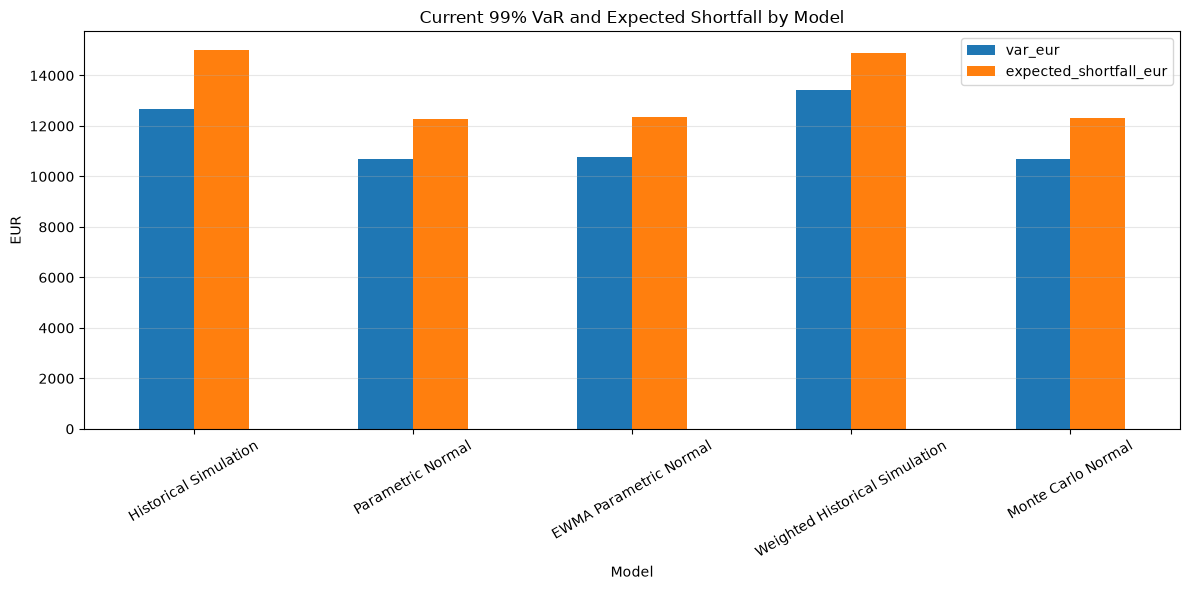

In [132]:
fig_current_models, ax = plt.subplots(figsize=(12, 6))

current_model_comparison.set_index("model")[
    ["var_eur", "expected_shortfall_eur"]
].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Current 99% VaR and Expected Shortfall by Model")
ax.set_xlabel("Model")
ax.set_ylabel("EUR")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig_current_models.savefig(
    CHARTS_DIR / "advanced_var_current_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

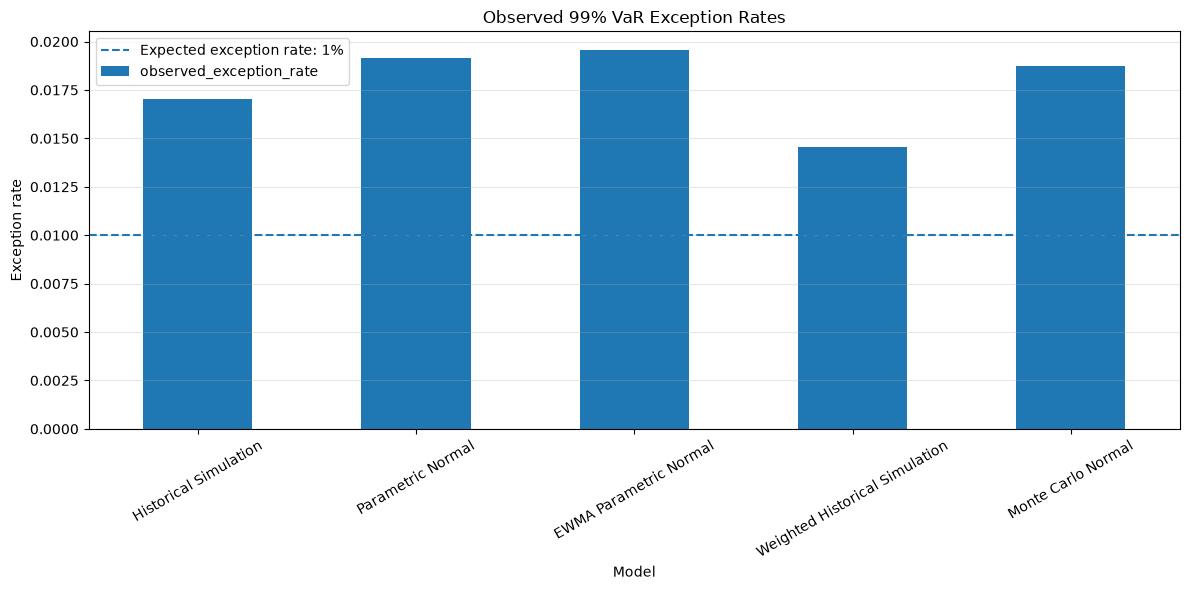

In [133]:
fig_exception_rates, ax = plt.subplots(figsize=(12, 6))

all_model_validation.set_index("model")[
    "observed_exception_rate"
].plot(
    kind="bar",
    ax=ax,
)

ax.axhline(
    TAIL_PROBABILITY,
    linestyle="--",
    linewidth=1.5,
    label="Expected exception rate: 1%",
)

ax.set_title("Observed 99% VaR Exception Rates")
ax.set_xlabel("Model")
ax.set_ylabel("Exception rate")
ax.tick_params(axis="x", rotation=30)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig_exception_rates.savefig(
    CHARTS_DIR / "advanced_var_exception_rate_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

In [134]:
current_model_comparison.to_csv(
    TABLES_DIR / "advanced_var_current_model_comparison.csv",
    index=False,
)

all_model_validation.to_csv(
    TABLES_DIR / "advanced_var_validation_comparison.csv",
    index=False,
)

model_ranking.to_csv(
    TABLES_DIR / "advanced_var_model_ranking.csv",
    index=False,
)

print("Final Day 2 comparison outputs saved.")

Final Day 2 comparison outputs saved.


## 5. Day 2 conclusions

Five one-day 99% VaR models were compared:

1. Historical Simulation
2. Parametric Normal
3. EWMA Parametric Normal
4. Weighted Historical Simulation
5. Monte Carlo Normal

Weighted Historical Simulation produces the fewest exceptions and the lowest
conditional-coverage likelihood-ratio statistic. It is therefore the strongest
model within the current comparison. Nevertheless, it still fails
unconditional coverage, exception independence and combined conditional
coverage.

EWMA Parametric Normal is the only model for which exception independence is
not rejected at the 5% level. However, it produces the largest number of
exceptions and fails unconditional and conditional coverage.

Parametric Normal and Monte Carlo Normal produce nearly identical static and
backtesting results. This confirms that Monte Carlo simulation does not
improve a model when the same normal-distribution, covariance and linear
portfolio assumptions are retained.

All five models fail conditional coverage. The findings indicate that the
portfolio's P&L distribution contains fat tails, volatility regime changes
and stressed-period dependence that are not adequately represented by the
current models.

The next development stage should therefore focus on models that combine
time-varying volatility with non-normal empirical innovations, such as
Filtered Historical Simulation and Student-t volatility models.